[*********************100%***********************]  1 of 1 completed

Date
2023-01-04    0.025665
2023-01-05    0.040111
2023-01-06    0.005838
2023-01-09   -0.009497
2023-01-10    0.001598
Name: HSBA.L, dtype: float64


<Axes: xlabel='Date'>

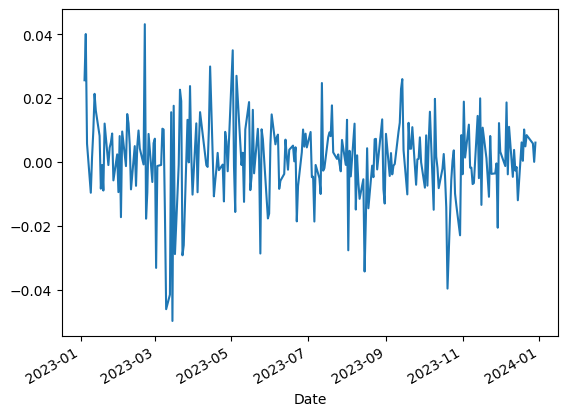

In [24]:
import yfinance as yf
import pandas as pd
# Download historical data for HSBC Holdings plc (HSBA.L) from Yahoo Finance
data = yf.download("HSBA.L", start="2023-01-01", end="2024-01-01")
returns = data["Close"].squeeze().pct_change().dropna()
# Display the first few rows of the returns and plot them
print(returns.head())
returns.plot()

In [25]:
# Value at Risk (VaR) calculations
import numpy as np
from scipy.stats import norm

# Historical VaR
def historical_var(returns, confidence = 0.99):
    return np.percentile(returns.dropna(), (1 - confidence) * 100)

# Parametric VaR
def parametric_var(returns, confidence = 0.99):
    mu = returns.mean()
    sigma = returns.std()
    return mu - sigma * norm.ppf(confidence)

In [26]:
portfolio_value = 10000 

h_var = historical_var(returns)
p_var = parametric_var(returns)

print(f"Portfolio value: £{portfolio_value:,.2f}")
print(f"Historical 99%: {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%: {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")

Portfolio value: £10,000.00
Historical 99%: -0.0404 → £404.19
Parametric 99%: -0.0297 → £296.68


In [27]:
def position_sizer(var_decimal, var_limit_gbp, current_price, proposed_shares=None):
    max_position_gbp = var_limit_gbp / abs(var_decimal)
    max_shares = int(max_position_gbp / current_price)
    
    print(f"VaR limit:          £{var_limit_gbp:,.2f}")
    print(f"Max position size:  £{max_position_gbp:,.2f}")
    print(f"Max shares:         {max_shares}")
    
    if proposed_shares is not None:
        proposed_value = proposed_shares * current_price
        proposed_var = proposed_value * abs(var_decimal)
        print(f"\nProposed shares:    {proposed_shares}")
        print(f"Proposed value:     £{proposed_value:,.2f}")
        print(f"Proposed VaR:       £{proposed_var:,.2f}")
        
        if proposed_shares > max_shares:
            print(f"\n⚠️  WARNING: Exceeds limit — reduce to {max_shares} shares")
        else:
            print(f"\n✅ Position is within your VaR limit")



In [28]:
current_price = data["Close"].squeeze().iloc[-1]

position_sizer(
    var_decimal=h_var,
    var_limit_gbp=300,
    current_price=current_price,
    proposed_shares=500
)

VaR limit:          £300.00
Max position size:  £7,422.22
Max shares:         11

Proposed shares:    500
Proposed value:     £317,162.75
Proposed VaR:       £12,819.46

⚠️  WARNING: Exceeds limit — reduce to 11 shares


In [29]:
from scipy.stats import t

def t_var(returns, confidence=0.99):
    nu, mu, sigma = t.fit(returns)
    return float(t.ppf(1 - confidence, nu, mu, sigma))

In [30]:
t_v = t_var(returns)

print(f"Portfolio value:    £{portfolio_value:,.2f}")
print(f"Historical 99%:     {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%:     {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")
print(f"T-distribution 99%: {t_v:.4f} → £{abs(t_v) * portfolio_value:,.2f}")
print(f"\nDegrees of freedom (ν): {t.fit(returns)[0]:.2f}")

Portfolio value:    £10,000.00
Historical 99%:     -0.0404 → £404.19
Parametric 99%:     -0.0297 → £296.68
T-distribution 99%: -0.0348 → £347.99

Degrees of freedom (ν): 3.85


In [ ]:
def drawdown_analysis(returns, portfolio_value):
    cumulative = portfolio_value * (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    print(f"Starting portfolio value:  £{portfolio_value:,.2f}")
    print(f"Final portfolio value:     £{cumulative.iloc[-1]:,.2f}")
    print(f"Maximum drawdown:          {max_dd:.2%}")
    print(f"Worst single day loss:     {returns.min():.2%}")
    
    return cumulative, drawdown

In [ ]:
cumulative, drawdown = drawdown_analysis(returns, portfolio_value)